In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

#handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

#encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic[target]

# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)

In [3]:
#Decision Tree

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training Accuracy", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing Accuracy", accuracy_score(y_test, y_pred_test) * 100, "%")

Training Accuracy 97.91332263242376 %
Testing Accuracy 76.11940298507463 %


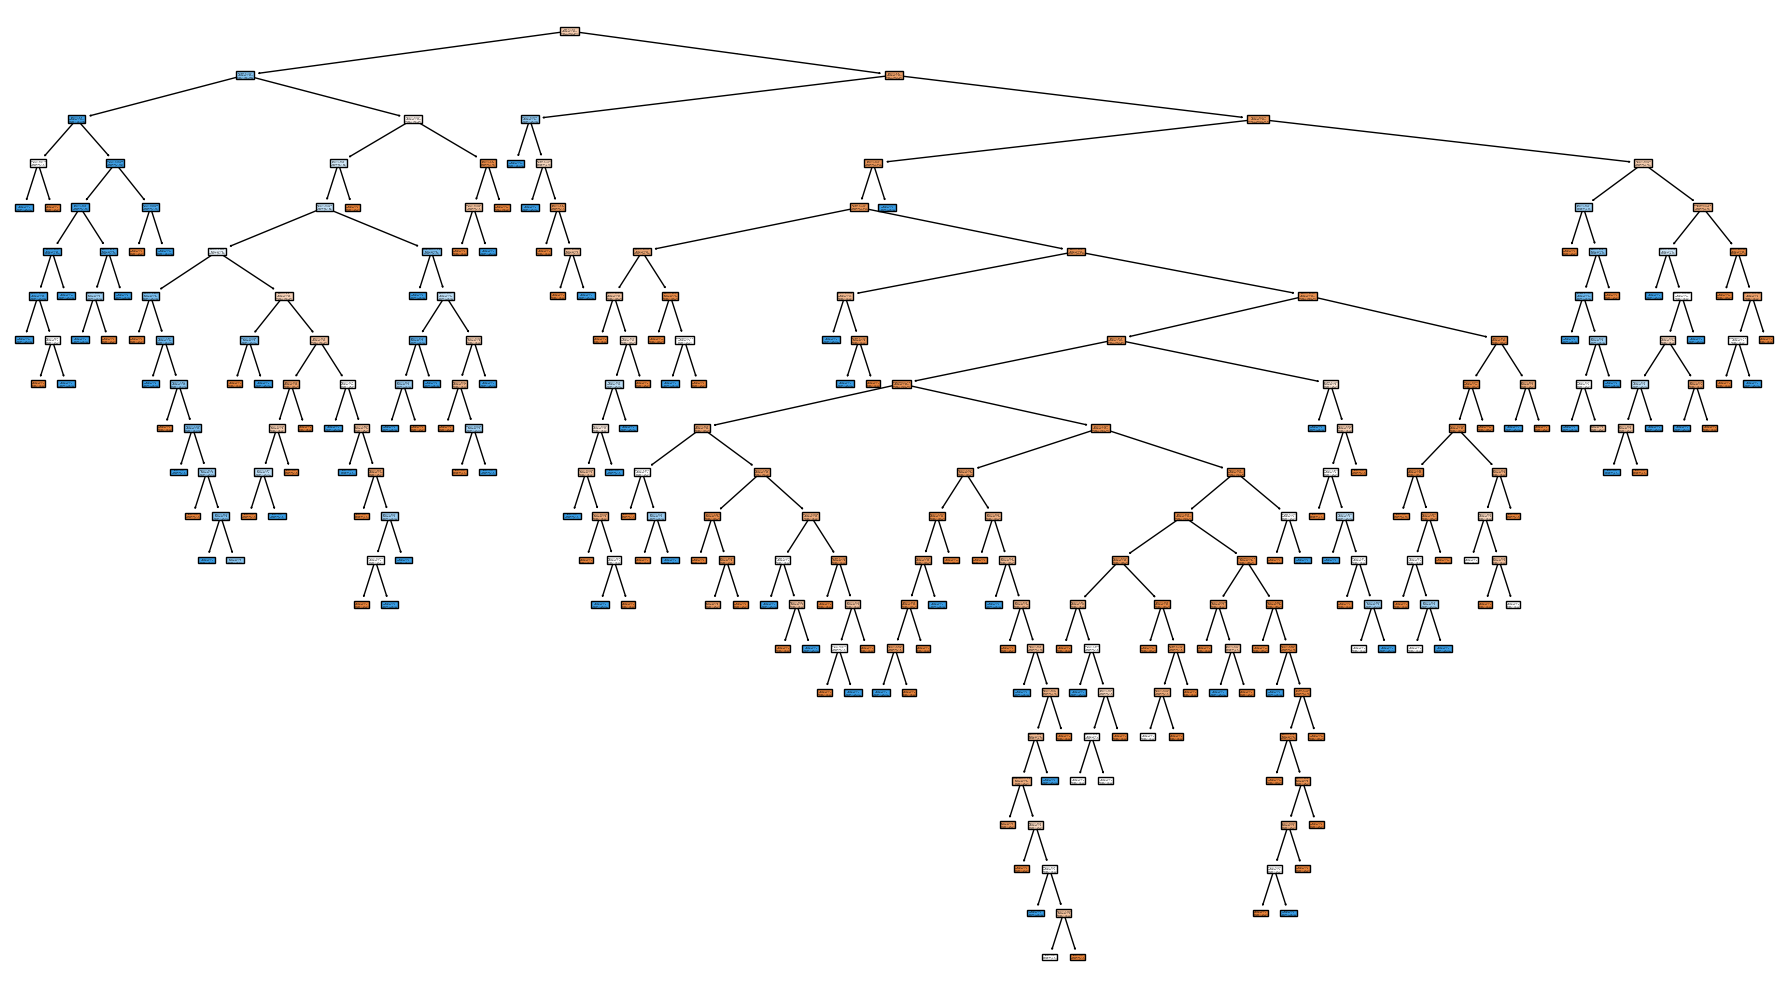

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True
)

plt.tight_layout()

In [8]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 201,
    oob_score = False
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB score: ", rf.oob_score)
print("testing accuracy: ", accuracy_score(y_test, y_pred))

d:\Develops\Apna_College\Data-Science-interview\apna_college\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


OOB score:  False
testing accuracy:  0.7798507462686567


In [12]:
# Bagging classifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter = 1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators = 291
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)
print("accuracy: ",accuracy_score(y_test, y_pred))

d:\Develops\Apna_College\Data-Science-interview\apna_college\lib\site-packages\sklearn\ensemble\_bagging.py:930: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuracy:  0.7985074626865671
